In [1]:
# Make use of a GPU or MPS (Apple) if one is available.  (see module 3.2)
import pandas
import torch
import pandas as pd
import numpy as np
from torch import nn, optim
import Training_options
device = Training_options.assess_device()
print(device)

cuda


In [2]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import time
from torch.utils.data import DataLoader

In [3]:
PROJECT_DIR = Path.cwd()
PREPARED_DIR = PROJECT_DIR #/ "outputs" / "prepared_notebook"
RUN_DIR = PROJECT_DIR #/ "outputs" / "training_options"

In [4]:
lookBack = 28
maxStores = None
historyStart = None
trainStride = 7
epochs = 50
l2_lambda = 1e-4
l1_lambda = 1e-5
patience = 30
#MLP
BatchSize = 1024

In [6]:
data_dict = Training_options.read_split(test = os.path.join(PREPARED_DIR,"test_prepared.csv"), train = os.path.join(PREPARED_DIR,"train_prepared.csv"), valid = os.path.join(PREPARED_DIR,"validation_prepared.csv"), device=device)

In [7]:
train_df = data_dict["traindf"]
val_df = data_dict["valdf"]
test_df = data_dict["testdf"]
selectedStores = data_dict["selectedStores"]
eligibleStores = data_dict["eligibleStores"]
horizon = data_dict["Horizon"]
valDates = data_dict["valDates"]
testDates = data_dict["testDates"]
fullPreparedtestRows = data_dict["fullPreparedtestRows"]
categorical_features = data_dict["categoricalFeatures"]
numeric_features = data_dict["numericalFeatures"]

display(pd.DataFrame([
    {"split": name, "rows": len(frame), "stores": frame["Store"].nunique(),
     "start": frame["Date"].min().date(), "end": frame["Date"].max().date()}
    for name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]
]))

print(f"Selected {len(selectedStores)} of {len(eligibleStores)} eligible stores.")
print(f"Training Hroeizon: {horizon} days; validation: {len(valDates)}; test: {len(testDates)}.")
print(f"Test coverage: {len(test_df):,} / {fullPreparedtestRows:,} prepared rows.")

,split,rows,stores,start,end
0,train,737279,856,2013-01-01,2015-06-19
1,validation,35952,856,2015-06-20,2015-07-31
2,test,41088,856,2015-08-01,2015-09-17


Selected 856 of 856 eligible stores.
Training Hroeizon: 48 days; validation: 42; test: 48.
Test coverage: 41,088 / 41,088 prepared rows.


In [8]:
numeric_means = train_df[numeric_features].astype(float).mean().fillna(0.0)
numeric_stds = train_df[numeric_features].astype(float).std(ddof=0).replace(0, 1).fillna(1.0)
category_levels = {
    col: sorted(train_df[col].fillna("missing").astype(str).unique().tolist())
    for col in categorical_features
}
store_to_index = {int(store): i for i, store in enumerate(selectedStores)}
train_log_sales = np.log1p(train_df["Sales"].to_numpy(dtype=np.float64))
sales_mean = float(train_log_sales.mean())
sales_std = max(float(train_log_sales.std()), 1e-6)

encoded_feature_names = numeric_features.copy()
for col, levels in category_levels.items():
    encoded_feature_names.extend([f"{col}={level}" for level in levels] + [f"{col}=unknown"])

print("Features per future day:", len(encoded_feature_names))
print("Features per historical day:", len(encoded_feature_names) + 1)
print("Log-sales training mean/std:", round(sales_mean, 3), round(sales_std, 3))

Features per future day: 47
Features per historical day: 48
Log-sales training mean/std: 7.251 3.317


Training windows: 95384
Skipped windows crossing missing dates: 1800
One history: (28, 48)
One future feature block: (48, 47)
One target block: (48,)


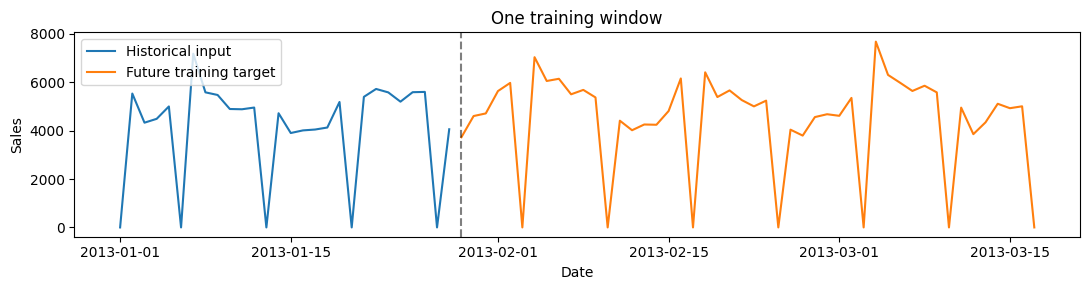

In [9]:

train_dataset = Training_options.SalesWindowDataset(train_df, lookBack, horizon, trainStride, store_to_index, numeric_features, numeric_means, category_levels, numeric_stds, sales_mean, sales_std)

example_history, example_future, example_store, example_target = train_dataset[0]
print("Training windows:", len(train_dataset))
print("Skipped windows crossing missing dates:", train_dataset.skipped_windows)
print("One history:", tuple(example_history.shape))
print("One future feature block:", tuple(example_future.shape))
print("One target block:", tuple(example_target.shape))

store_id, start = train_dataset.windows[0]
history, _, target, dates = train_dataset.series[store_id]
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(dates[start - lookBack:start], np.expm1(history[start - lookBack:start, 0] * sales_std + sales_mean),
        label="Historical input")
ax.plot(dates[start:start + horizon], np.expm1(target[start:start + horizon] * sales_std + sales_mean),
        label="Future training target")
ax.axvline(dates[start], color="black", linestyle="--", alpha=0.5)
ax.set(title="One training window", xlabel="Date", ylabel="Sales")
ax.legend()
fig.tight_layout()
plt.show()

In [10]:
val_inputs, val_rows = Training_options.make_forecast_inputs(train_df, val_df.drop(columns="Sales"), horizon, lookBack, store_to_index,
                                                             numeric_features,numeric_means, category_levels, numeric_stds,
                                                             sales_mean, sales_std)
val_labels = val_rows[["Store", "Date"]].merge(
    val_df[["Store", "Date", "Sales"]], on=["Store", "Date"],
    how="left", validate="one_to_one", sort=False
)["Sales"].to_numpy()
assert np.isfinite(val_labels).all()
print("Validation input shapes:", [tuple(tensor.shape) for tensor in val_inputs])
print("Last historical date:", valDates[0] - pd.Timedelta(days=1))
print("First forecast date:", valDates[0])

Validation input shapes: [(856, 28, 48), (856, 42, 47), (856,)]
Last historical date: 2015-06-19 00:00:00
First forecast date: 2015-06-20 00:00:00


# MLP

In [ ]:
mlP_categorical_features = ["Store", "DayOfWeek","StateHoliday", "StoreType", "Assortment"]
mlp_train_df = train_df
mlp_val_df = val_df

category_maps = {}
category_cardinalities = {}
for column in mlP_categorical_features:
    values = sorted(Training_options.as_category_text(mlp_train_df[column]).unique())
    mapping = {"unknown": 0}
    mapping.update({value: index + 1 for index, value in enumerate(values)})
    category_maps[column] = mapping
    category_cardinalities[column] = len(mapping)

train_cat = Training_options.encode_categorical_frame(mlp_train_df, mlP_categorical_features, category_maps)
val_cat = Training_options.encode_categorical_frame(mlp_val_df, mlP_categorical_features, category_maps)
test_cat = Training_options.encode_categorical_frame(test_df, mlP_categorical_features, category_maps)

category_summary = pd.DataFrame(
    {
        "feature": list(category_cardinalities.keys()),
        "n_categories_including_unknown": list(category_cardinalities.values()),
    }
)

display(category_summary)

train_num = Training_options.scale_numeric_frame(mlp_train_df, numeric_features, numeric_means, numeric_stds)
val_num = Training_options.scale_numeric_frame(val_df, numeric_features, numeric_means, numeric_stds)
test_num = Training_options.scale_numeric_frame(test_df, numeric_features, numeric_means, numeric_stds)

display(train_num.head())


mlp_train_df["log_sales"] = np.log1p(mlp_train_df["Sales"].clip(lower = 0))
mlp_val_df["log_sales"] = np.log1p(mlp_val_df["Sales"].clip(lower = 0))

mlp_train_dataset = Training_options.StoreSalesDataset(train_cat, train_num, mlp_train_df["log_sales"])
mlp_val_dataset = Training_options.StoreSalesDataset(val_cat, val_num, mlp_val_df["log_sales"])
mlp_test_dataset = Training_options.StoreSalesDataset(test_cat, test_num)

mlp_train_loader = Training_options.make_dataloader(mlp_train_dataset, batch_size=BatchSize, shuffle=True)
mlp_val_loader = Training_options.make_dataloader(mlp_val_dataset, batch_size=BatchSize, shuffle=False)
mlp_test_loader = Training_options.make_dataloader(mlp_test_dataset, batch_size=BatchSize, shuffle=False)

print("train batches:", len(mlp_train_loader))
print("validation batches:", len(mlp_val_loader))
print("test batches:", len(mlp_test_loader))

embedding_cardinalities = [category_cardinalities[column] for column in mlP_categorical_features]
embedding_dimensions = [Training_options.embedding_size(cardinality) for cardinality in embedding_cardinalities]

print("Embedding cardinalities:", embedding_cardinalities)
print("Embedding dimensions:", embedding_dimensions)

,feature,n_categories_including_unknown
0,Store,857
1,DayOfWeek,8
2,StateHoliday,5
3,StoreType,5
4,Assortment,4


,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,year,...,is_weekend,is_month_start,is_month_end,days_since_start,competition_open_months,promo2_active,dow_sin,dow_cos,month_sin,month_cos
0,-2.199920,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,5.382556,-0.182419,-1.682166,0.197809,-0.429971,1.378848,-0.311482,0.499684,1.277477
1,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.678352,0.197809,-0.429971,0.613916,-1.271234,0.499684,1.277477
2,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.674538,0.197809,-0.429971,-0.612940,-1.271234,0.499684,1.277477
3,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,-0.630617,-0.185785,-0.182419,-1.670724,0.197809,-0.429971,-1.377872,-0.311482,0.499684,1.277477
4,0.454562,-0.78702,2.184374,-0.52644,1.092215,0.770983,-1.146088,-0.854765,-1.146087,-1.024758,...,1.585749,-0.185785,-0.182419,-1.666910,0.197809,-0.429971,-1.104871,0.885308,0.499684,1.277477


train batches: 720
validation batches: 36
test batches: 41
Embedding cardinalities: [857, 8, 5, 5, 4]
Embedding dimensions: [50, 4, 2, 2, 2]


In [ ]:
model = Training_options.TabularSalesModel_MLP(embedding_cardinalities=embedding_cardinalities,
                                               embedding_dimensions= embedding_dimensions,
                                               n_numeric_features= len(numeric_features), dropout=0.15)
model.to(device)
loss_function = nn.MSELoss()
optimizer = torch.optim.AdamW(params= model.parameters(), lr = 0.01, weight_decay=l2_lambda)
scheduler = Training_options.create_scheduler(optimizer)

m_res, hist, b_ep = Training_options.mlp_basic_training_loop(model, mlp_train_loader, loss_function, optimizer,
                                                            epochs, mlp_val_loader, scheduler, l1_lambda, patience,
                                                            0.001, 2, os.path.join(RUN_DIR, "mlp_scheduler.pt"),device)

Epoch 2/50, Train Loss: 0.1444, Validation Loss: 0.1190, Validation MAE: 0.2834
Epoch 4/50, Train Loss: 0.0704, Validation Loss: 0.0303, Validation MAE: 0.1292
Epoch 6/50, Train Loss: 0.0393, Validation Loss: 0.0595, Validation MAE: 0.2064
Epoch 8/50, Train Loss: 0.0463, Validation Loss: 0.0228, Validation MAE: 0.1182
Epoch 10/50, Train Loss: 0.0263, Validation Loss: 0.0272, Validation MAE: 0.1211
Epoch 12/50, Train Loss: 0.0268, Validation Loss: 0.0195, Validation MAE: 0.1070
Epoch 14/50, Train Loss: 0.0268, Validation Loss: 0.0269, Validation MAE: 0.1263
Epoch 16/50, Train Loss: 0.0257, Validation Loss: 0.0213, Validation MAE: 0.1088
Epoch 18/50, Train Loss: 0.0252, Validation Loss: 0.0277, Validation MAE: 0.1269
Epoch 20/50, Train Loss: 0.0245, Validation Loss: 0.0351, Validation MAE: 0.1444
Epoch 22/50, Train Loss: 0.0234, Validation Loss: 0.0493, Validation MAE: 0.1807
Epoch 24/50, Train Loss: 0.0248, Validation Loss: 0.0463, Validation MAE: 0.1676
Epoch 26/50, Train Loss: 0.0238,

In [ ]:
print(hist["train_loss"])
print(hist["valid_loss"])
print(hist["valid_mae"])

[0.6703985525295139, 0.14441409468029937, 0.10759864907918705, 0.07040304546761844, 0.04783642722500695, 0.03929134943367293, 0.03805417385107527, 0.04631715626714544, 0.025970898935985233, 0.02625028658528916, 0.026183059325234757, 0.026818131822316595, 0.032411141706527105, 0.026841338760116035, 0.025068327038186705, 0.02567125824668134, 0.025241961997623245, 0.025191982259922144, 0.025969141918338007, 0.024536408727160758, 0.023289954856348535, 0.023385124834668307, 0.023404821525845262, 0.02483718511260425, 0.023413494506126478, 0.02384256182833471, 0.02321039536424602, 0.02349426227673474, 0.023159240785106602, 0.023692851143682168, 0.02457419557419295, 0.023097002723564703, 0.023757568803719348, 0.02370593821009, 0.023491097394273512, 0.024016172600547888, 0.02426268125159873, 0.024146260244823577, 0.023553874590692834, 0.02296768248003597, 0.022261050736738577, 0.02246121833126785]
[0.031194973854711972, 0.11902003154874803, 0.05400536401329117, 0.030299308840359484, 0.038983330

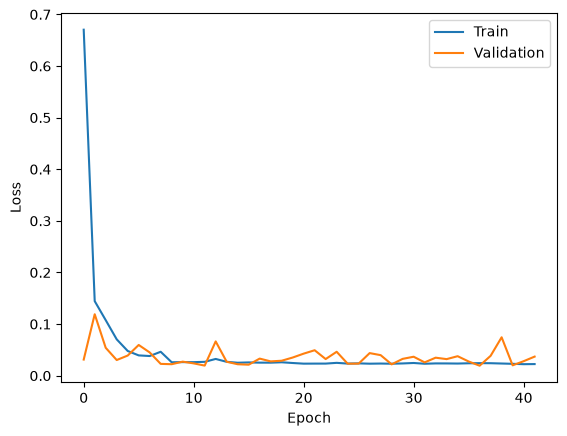

In [ ]:
plt.plot(hist["train_loss"], label="Train")
plt.plot(hist["valid_loss"], label="Validation")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
m_res.eval()

predictions = []

with torch.inference_mode():
    for categorical_inputs, numeric_inputs in mlp_test_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)

        preds = m_res(categorical_inputs, numeric_inputs)

        predictions.extend(preds.squeeze(-1).cpu().numpy())

# Convert predictions from normalized log-sales back to actual Sales
predicted_sales = np.expm1(predictions)
predicted_sales = np.maximum(predicted_sales, 0)

predicted_sales = np.where(test_df["Open"].to_numpy() == 0,0.0,predicted_sales)

test_predictions = pd.DataFrame({
    "Date": test_df["Date"].values,
    "Store": test_df["Store"].values,
    "Sales": predicted_sales
})

display(test_predictions.head())

,Date,Store,Sales
0,2015-08-01,1,4873.229492
1,2015-08-02,1,0.000000
2,2015-08-03,1,7254.111328
3,2015-08-04,1,5541.146973
4,2015-08-05,1,4890.337891


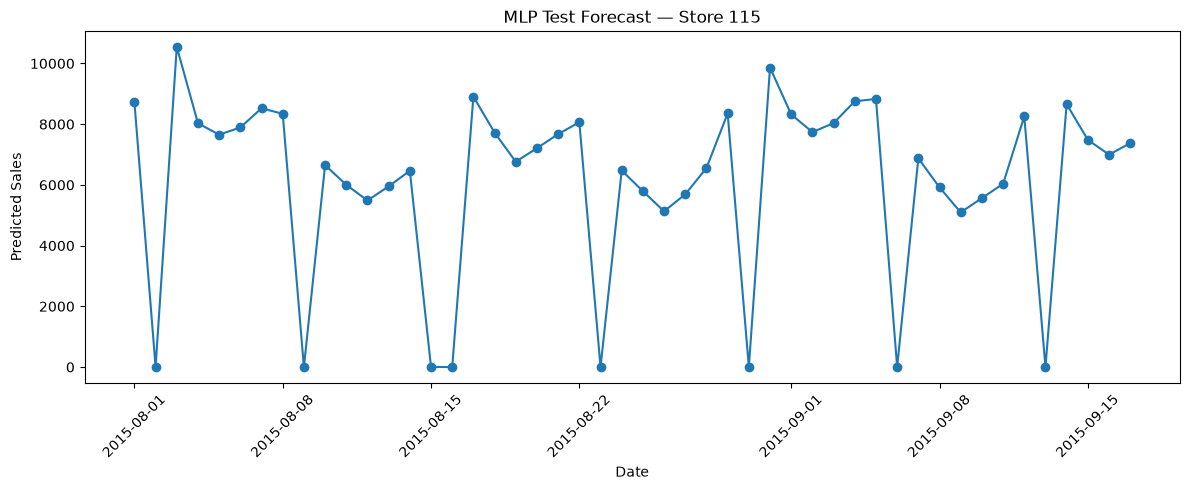

In [ ]:
store_to_plot = 115

plot_df = test_predictions[
    test_predictions["Store"] == store_to_plot
]

plt.figure(figsize=(12, 5))

plt.plot(
    plot_df["Date"],
    plot_df["Sales"],
    marker="o"
)

plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title(f"MLP Test Forecast — Store {store_to_plot}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
m_res.eval()

val_predictions = []
y_val = []

with torch.inference_mode():
    for categorical_inputs, numeric_inputs, y_valid in mlp_val_loader:
        categorical_inputs = categorical_inputs.to(device)
        numeric_inputs = numeric_inputs.to(device)

        preds = m_res(categorical_inputs, numeric_inputs)

        val_predictions.extend(
            preds.squeeze(-1).cpu().numpy()
        )

        y_val.extend(
            y_valid.squeeze(-1).cpu().numpy()
        )

# Convert log1p(Sales) → original Sales scale consistently for both prediction and target
val_predicted_sales = np.maximum(np.expm1(np.asarray(val_predictions, dtype=np.float64)), 0.0)
val_actual_sales = np.maximum(np.expm1(np.asarray(y_val, dtype=np.float64)), 0.0)

metrics = Training_options.regression_metrics(
    val_actual_sales,
    val_predicted_sales
)

print("MLP Metrics", metrics)

MLP Metrics {'rmspe': 0.15722853866365197, 'mse': 1109763.6356907282, 'rmse': 1053.453195776029, 'mae': 673.4658864837996, 'r2': 0.9150231630571817}


# Recurrent Models

In [11]:
MODEL_TYPES = ("RNN", "LSTM", "GRU")
hiddenSize = 32
numLayers = 1
dropout = 0.15
STORE_EMBEDDING_SIZE = 8
LEARNING_RATE = 0.001
rnn_batchSize = 64

rnn_train_loader = DataLoader(
        train_dataset, batch_size=rnn_batchSize, shuffle=True, num_workers=0,
        generator=torch.Generator().manual_seed(42),
    )

test_inputs, test_rows = Training_options.make_forecast_inputs(
    pd.concat([train_df, val_df], ignore_index=True),
    test_df.drop(columns="Id"),
    horizon,
    lookBack,
    store_to_index,
    numeric_features,
    numeric_means,
    category_levels,
    numeric_stds,
    sales_mean,
    sales_std
)

Epoch 2/50, Train Loss: 0.0089, Validation Loss: 0.0025, Validation MAE: 781.7238
Epoch 4/50, Train Loss: 0.0087, Validation Loss: 0.0024, Validation MAE: 765.9750
Epoch 6/50, Train Loss: 0.0087, Validation Loss: 0.0021, Validation MAE: 697.4925
Epoch 8/50, Train Loss: 0.0086, Validation Loss: 0.0020, Validation MAE: 709.8149
Epoch 10/50, Train Loss: 0.0086, Validation Loss: 0.0020, Validation MAE: 720.6566
Epoch 12/50, Train Loss: 0.0086, Validation Loss: 0.0020, Validation MAE: 692.3142
Epoch 14/50, Train Loss: 0.0085, Validation Loss: 0.0021, Validation MAE: 717.6170
Epoch 16/50, Train Loss: 0.0085, Validation Loss: 0.0022, Validation MAE: 726.3482
Epoch 18/50, Train Loss: 0.0085, Validation Loss: 0.0021, Validation MAE: 715.0487
Epoch 20/50, Train Loss: 0.0085, Validation Loss: 0.0021, Validation MAE: 737.6552
Epoch 22/50, Train Loss: 0.0085, Validation Loss: 0.0019, Validation MAE: 687.8755
Epoch 24/50, Train Loss: 0.0085, Validation Loss: 0.0021, Validation MAE: 734.5464
Epoch 26

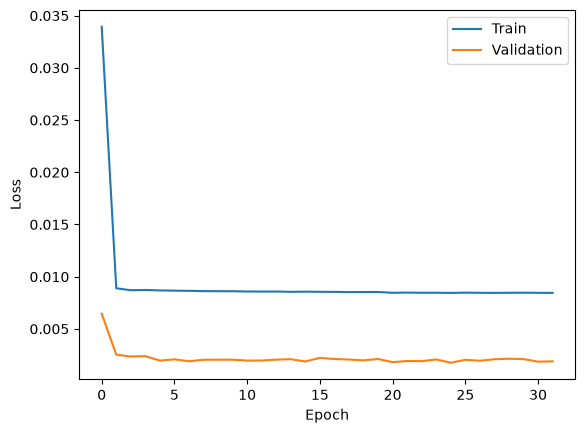

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
scaled min: -2.2067387
scaled max: 0.86844313
finite: True
largest predictions: [0.8054907  0.8105337  0.8148086  0.8181778  0.82092404 0.8273685
 0.8438422  0.8449022  0.8553844  0.86844313]
Test history finite: True
Test future finite: True


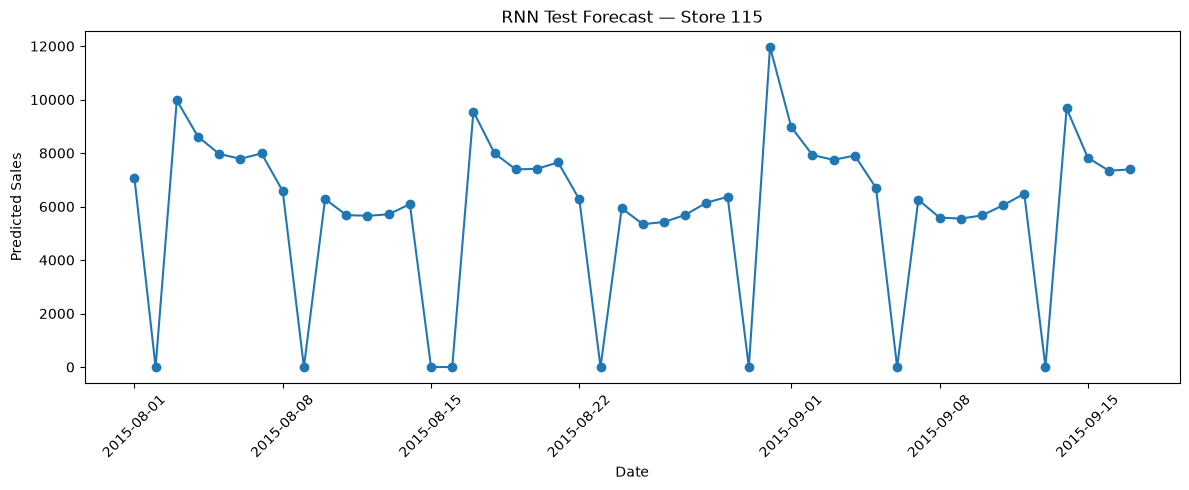

RNN Metrics {'rmspe': 0.16131220125026893, 'mse': 1573815.4821375182, 'rmse': 1254.518027824837, 'mae': 781.7237606608219, 'r2': 0.8794897767948218}
Epoch 2/50, Train Loss: 0.0085, Validation Loss: 0.0025, Validation MAE: 800.1426
Epoch 4/50, Train Loss: 0.0084, Validation Loss: 0.0019, Validation MAE: 658.9934
Epoch 6/50, Train Loss: 0.0083, Validation Loss: 0.0019, Validation MAE: 679.8567
Epoch 8/50, Train Loss: 0.0083, Validation Loss: 0.0020, Validation MAE: 706.9962
Epoch 10/50, Train Loss: 0.0083, Validation Loss: 0.0018, Validation MAE: 657.3248
Epoch 12/50, Train Loss: 0.0083, Validation Loss: 0.0018, Validation MAE: 660.1825
Epoch 14/50, Train Loss: 0.0083, Validation Loss: 0.0019, Validation MAE: 677.0827
Epoch 16/50, Train Loss: 0.0083, Validation Loss: 0.0020, Validation MAE: 692.3091
Epoch 18/50, Train Loss: 0.0083, Validation Loss: 0.0021, Validation MAE: 655.6314
Epoch 20/50, Train Loss: 0.0083, Validation Loss: 0.0023, Validation MAE: 760.6543
Epoch 22/50, Train Loss: 

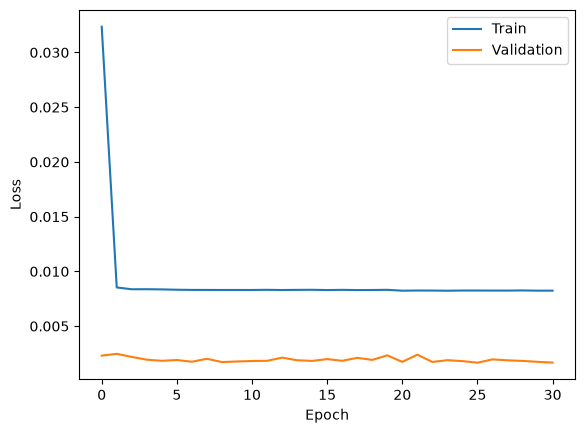

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
scaled min: -2.1965625
scaled max: 0.86354434
finite: True
largest predictions: [0.8286618  0.8292413  0.83074963 0.83389544 0.8351691  0.8392507
 0.84068394 0.85920453 0.8607185  0.86354434]
Test history finite: True
Test future finite: True


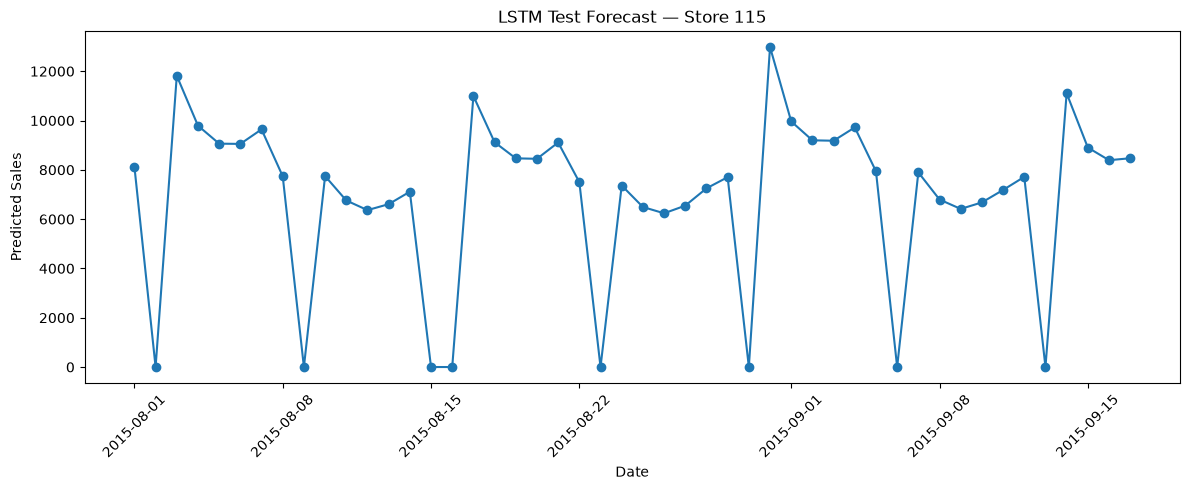

LSTM Metrics {'rmspe': 0.19191418950165665, 'mse': 1225828.9690094173, 'rmse': 1107.1716077507665, 'mae': 735.5434773159427, 'r2': 0.9061358054083557}
Epoch 2/50, Train Loss: 0.0082, Validation Loss: 0.0018, Validation MAE: 675.3881
Epoch 4/50, Train Loss: 0.0080, Validation Loss: 0.0018, Validation MAE: 655.2000
Epoch 6/50, Train Loss: 0.0080, Validation Loss: 0.0017, Validation MAE: 645.1890
Epoch 8/50, Train Loss: 0.0080, Validation Loss: 0.0029, Validation MAE: 856.1102
Epoch 10/50, Train Loss: 0.0080, Validation Loss: 0.0018, Validation MAE: 641.0492
Epoch 12/50, Train Loss: 0.0080, Validation Loss: 0.0018, Validation MAE: 649.6512
Epoch 14/50, Train Loss: 0.0080, Validation Loss: 0.0022, Validation MAE: 717.4373
Epoch 16/50, Train Loss: 0.0080, Validation Loss: 0.0019, Validation MAE: 684.8301
Epoch 18/50, Train Loss: 0.0080, Validation Loss: 0.0019, Validation MAE: 654.1340
Epoch 20/50, Train Loss: 0.0080, Validation Loss: 0.0018, Validation MAE: 650.6441
Epoch 22/50, Train Loss

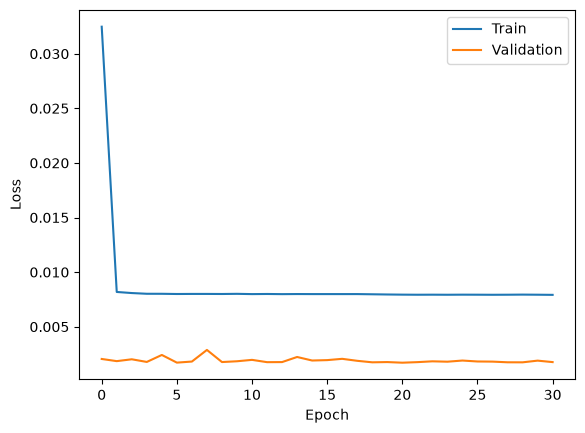

[4097    0 3846 3762 3346 3533 3317 4019    0 5197]
5953.514380284824 0 41551
scaled min: -2.214028
scaled max: 0.89536387
finite: True
largest predictions: [0.852753   0.8529251  0.85565645 0.8575792  0.8683025  0.87404954
 0.87438035 0.8828548  0.89318067 0.89536387]
Test history finite: True
Test future finite: True


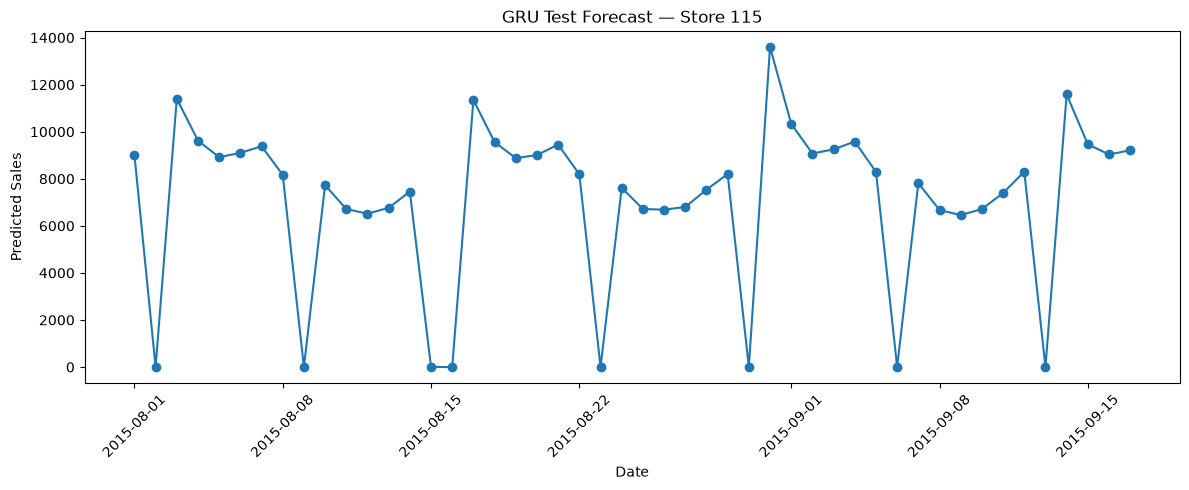

GRU Metrics {'rmspe': 0.16229201652213707, 'mse': 1164183.3071024865, 'rmse': 1078.9732652399161, 'mae': 686.6821011508816, 'r2': 0.9108561379761517}


,rmspe,mse,rmse,mae,r2
RNN,0.161312,1.573815e+06,1254.518028,781.723761,0.879490
LSTM,0.191914,1.225829e+06,1107.171608,735.543477,0.906136
GRU,0.162292,1.164183e+06,1078.973265,686.682101,0.910856


In [ ]:
baseline_recurrent_metrics = {}

for model_type in MODEL_TYPES:
    model = Training_options.RecurrentSalesModel(model_type, encoded_feature_names,hiddenSize, numLayers, dropout, STORE_EMBEDDING_SIZE, selectedStores)
    model.to(device)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=l2_lambda)
    scheduler = Training_options.create_scheduler(optimizer)

    trained_model, history_frame, best_epoch = Training_options.recurrent_training_loop(model,rnn_train_loader,loss_function, optimizer,epochs, val_inputs, val_rows,val_labels, scheduler,
                                                                                        l1_lambda, patience, 0.001,2, os.path.join(RUN_DIR, "rnn_scheduler.pt"),device, rnn_batchSize, sales_std, sales_mean, horizon )

    plt.plot(history_frame["train_loss"], label="Train")
    plt.plot(history_frame["valid_loss"], label="Validation")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    print(val_labels[:10])
    print(val_labels.mean(), val_labels.min(), val_labels.max())

    trained_model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(test_inputs[0]), rnn_batchSize):
            batch = [tensor[start:start + rnn_batchSize].to(device) for tensor in test_inputs]
            outputs.append(trained_model(*batch, horizon).cpu().numpy())

    test_scaled = np.concatenate(outputs, axis=0).ravel()

    print("scaled min:", np.min(test_scaled))
    print("scaled max:", np.max(test_scaled))
    print("finite:", np.isfinite(test_scaled).all())

    print("largest predictions:",
      np.sort(test_scaled)[-10:])

    print("Test history finite:",
      np.isfinite(test_inputs[0].numpy()).all())

    print("Test future finite:",
      np.isfinite(test_inputs[1].numpy()).all())

    test_predictions_sales = Training_options.decode_sales(
    test_scaled,
    test_rows["Open"].to_numpy(), sales_std, sales_mean)

    test_predictions = test_rows[["Store", "Date"]].copy()

    test_predictions["Sales"] = test_predictions_sales

    store_to_plot = 115

    plot_df = test_predictions[
        test_predictions["Store"] == store_to_plot
    ]

    plt.figure(figsize=(12, 5))

    plt.plot(
        plot_df["Date"],
        plot_df["Sales"],
        marker="o"
    )

    plt.xlabel("Date")
    plt.ylabel("Predicted Sales")
    plt.title(f"{model_type} Test Forecast — Store {store_to_plot}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    trained_model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(val_inputs[0]), rnn_batchSize):
            batch = [tensor[start:start + rnn_batchSize].to(device) for tensor in val_inputs]
            outputs.append(trained_model(*batch, horizon).cpu().numpy())

    val_scaled = np.concatenate(outputs, axis=0).ravel()

    val_predictions_sales = Training_options.decode_sales(
    val_scaled,
    val_rows["Open"].to_numpy(),sales_std, sales_mean)

    metrics = Training_options.regression_metrics(
    val_labels,
    val_predictions_sales)

    print(model_type, "Metrics", metrics)
    baseline_recurrent_metrics[model_type] = metrics

baseline_recurrent_metrics_frame = pd.DataFrame(baseline_recurrent_metrics).T
display(baseline_recurrent_metrics_frame)

# Bayesian optimization for RNN, LSTM and GRU

The three recurrent families are optimized independently because their response surfaces are different. Each candidate is trained only on the training split and is selected by **validation RMSPE on the original Sales scale**. The test split is not used anywhere in hyperparameter selection.

The search uses logarithmic learning-rate and weight-decay coordinates, typed integer parameters for powers-of-two choices, RMSPE-based early stopping, fixed seeds for fair candidate comparisons, and optional multi-seed confirmation of the strongest configurations.

In [14]:
# BayesianOptimization 3.x is required for typed integer bounds.
# If the import fails, run this once in a separate notebook cell and restart the kernel:
# %pip install "bayesian-optimization>=3.0,<4"

import copy
import gc
import random
from importlib.metadata import version as package_version

try:
    from bayes_opt import BayesianOptimization
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        'Install the notebook dependency with: %pip install "bayesian-optimization>=3.0,<4"'
    ) from error

BAYES_OPT_VERSION = package_version("bayesian-optimization")
if int(BAYES_OPT_VERSION.split(".", maxsplit=1)[0]) < 3:
    raise RuntimeError(
        f"bayesian-optimization {BAYES_OPT_VERSION} is installed; version 3.x or newer is required."
    )

BAYES_SEARCH_PRESETS = {
    # Use smoke only to verify that the complete pipeline runs.
    "smoke": {"init_points": 1, "n_iter": 1, "max_epochs": 2, "patience": 1},
    # Balanced is the default for the full 856-store CPU dataset.
    "balanced": {"init_points": 6, "n_iter": 14, "max_epochs": 25, "patience": 5},
    # Thorough is more appropriate for a final GPU-backed experiment.
    "thorough": {"init_points": 10, "n_iter": 30, "max_epochs": 40, "patience": 7},
}

BAYES_SEARCH_PRESET = "balanced"
BAYES_SEARCH = BAYES_SEARCH_PRESETS[BAYES_SEARCH_PRESET]
BAYES_RANDOM_STATE = 42
BAYES_REPEATS = 1
BAYES_MIN_DELTA = 1e-4
BAYES_VALIDATION_BATCH_SIZE = 256
BAYES_SCHEDULER_STEP_SIZE = 10
BAYES_SCHEDULER_GAMMA = 0.7
BAYES_L1_LAMBDA = 0.0  # AdamW weight decay is optimized instead.
BAYES_GP_ALPHA = 1e-4

# Multi-seed confirmation reduces the chance of selecting a lucky initialization.
BAYES_RUN_CONFIRMATION = BAYES_SEARCH_PRESET != "smoke"
BAYES_CONFIRM_TOP_K = 2
BAYES_CONFIRMATION_SEEDS = (101, 202, 303)

display(pd.DataFrame([{
    "bayesian_optimization_version": BAYES_OPT_VERSION,
    "search_preset": BAYES_SEARCH_PRESET,
    "models": ", ".join(MODEL_TYPES),
    "trials_per_model": 1 + BAYES_SEARCH["init_points"] + BAYES_SEARCH["n_iter"],
    "max_epochs_per_trial": BAYES_SEARCH["max_epochs"],
    "confirmation_enabled": BAYES_RUN_CONFIRMATION,
}]))

,bayesian_optimization_version,search_preset,models,trials_per_model,max_epochs_per_trial,confirmation_enabled
0,3.3.0,balanced,"RNN, LSTM, GRU",21,25,True


In [15]:
GRADIENT_CLIP_CHOICES = (0.1, 0.5, 1.0, 5.0)

# Powers are decoded as powers of two. This keeps the search compact and ordered.
RECURRENT_BAYESIAN_BOUNDS = {
    "log_lr": (-4.5, -2.5),                       # 3.16e-5 to 3.16e-3
    "dropout": (0.0, 0.35),
    "log_weight_decay": (-8.0, -3.0),           # 1e-8 to 1e-3
    "batch_power": (5, 8, int),                 # 32, 64, 128, 256
    "hidden_power": (5, 7, int),                # 32, 64, 128
    "num_layers": (1, 3, int),
    "store_embedding_power": (2, 5, int),       # 4, 8, 16, 32
    "clip_choice": (0, 3, int),                 # index in GRADIENT_CLIP_CHOICES
}

# Register the current values of every optimized dimension before random exploration.
RECURRENT_BASELINE_PROBE = {
    "log_lr": -3.0,
    "dropout": 0.15,
    "log_weight_decay": -4.0,
    "batch_power": 6,
    "hidden_power": 5,
    "num_layers": 1,
    "store_embedding_power": 3,
    "clip_choice": 0,
}

RECURRENT_PARAMETER_KEYS = (
    "model_type", "lr", "dropout", "weight_decay", "l1_lambda",
    "batch_size", "hidden_size", "num_layers", "store_embedding_size",
    "gradient_clip", "scheduler_step_size", "scheduler_gamma",
)


def bo_seed_everything(random_state=42):
    random_state = int(random_state)
    random.seed(random_state)
    np.random.seed(random_state)
    torch.manual_seed(random_state)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(random_state)


def bo_decode_recurrent_params(
    model_type, log_lr, dropout, log_weight_decay, batch_power, hidden_power,
    num_layers, store_embedding_power, clip_choice,
):
    model_type = str(model_type).upper()
    if model_type not in MODEL_TYPES:
        raise ValueError(f"Unsupported recurrent model: {model_type}")
    clip_index = int(np.clip(round(float(clip_choice)), 0, len(GRADIENT_CLIP_CHOICES) - 1))
    return {
        "model_type": model_type,
        "lr": 10.0 ** float(log_lr),
        "dropout": float(dropout),
        "weight_decay": 10.0 ** float(log_weight_decay),
        "l1_lambda": float(BAYES_L1_LAMBDA),
        "batch_size": 2 ** int(round(float(batch_power))),
        "hidden_size": 2 ** int(round(float(hidden_power))),
        "num_layers": int(round(float(num_layers))),
        "store_embedding_size": 2 ** int(round(float(store_embedding_power))),
        "gradient_clip": GRADIENT_CLIP_CHOICES[clip_index],
        "scheduler_step_size": int(BAYES_SCHEDULER_STEP_SIZE),
        "scheduler_gamma": float(BAYES_SCHEDULER_GAMMA),
    }


def bo_params_from_record(record):
    params = {key: record[key] for key in RECURRENT_PARAMETER_KEYS}
    params["model_type"] = str(params["model_type"]).upper()
    for key in ("batch_size", "hidden_size", "num_layers", "store_embedding_size", "scheduler_step_size"):
        params[key] = int(params[key])
    for key in ("lr", "dropout", "weight_decay", "l1_lambda", "gradient_clip", "scheduler_gamma"):
        params[key] = float(params[key])
    if "best_epoch" in record:
        params["best_epoch"] = int(record["best_epoch"])
    return params


def bo_make_train_loader(dataset, batch_size, random_state):
    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(int(random_state)),
    )


def bo_predict_recurrent_scaled(model, inputs, forecast_horizon, batch_size, target_device):
    model.eval()
    outputs = []
    with torch.inference_mode():
        for start in range(0, len(inputs[0]), int(batch_size)):
            batch = [tensor[start:start + int(batch_size)].to(target_device) for tensor in inputs]
            outputs.append(model(*batch, forecast_horizon).detach().cpu().numpy())
    if not outputs:
        raise ValueError("Prediction inputs are empty.")
    return np.concatenate(outputs, axis=0).reshape(-1)


def bo_release_memory():
    gc.collect()
    if torch.cuda.is_available() and torch.device(device).type == "cuda":
        torch.cuda.empty_cache()


def bo_fit_recurrent_candidate(
    params, train_data, validation_inputs, validation_rows, validation_labels,
    random_state, max_epochs, patience, min_delta, validation_batch_size,
):
    bo_seed_everything(random_state)
    train_loader = bo_make_train_loader(train_data, params["batch_size"], random_state)
    model = Training_options.RecurrentSalesModel(
        params["model_type"],
        encoded_feature_names,
        params["hidden_size"],
        params["num_layers"],
        params["dropout"],
        params["store_embedding_size"],
        selectedStores,
    ).to(device)
    loss_function = nn.MSELoss()
    candidate_optimizer = torch.optim.AdamW(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    candidate_scheduler = Training_options.create_scheduler(
        candidate_optimizer,
        step_size=params["scheduler_step_size"],
        gamma=params["scheduler_gamma"],
    )

    validation_labels = np.asarray(validation_labels, dtype=np.float64).reshape(-1)
    validation_open = validation_rows["Open"].to_numpy().reshape(-1)
    history = []
    best_score = float("inf")
    best_epoch = 0
    best_metrics = None
    best_state = None
    stale_epochs = 0

    for epoch in range(1, int(max_epochs) + 1):
        model.train()
        squared_error_sum = 0.0
        target_count = 0
        current_lr = candidate_optimizer.param_groups[0]["lr"]

        for past, future, stores, targets in train_loader:
            past, future, stores, targets = [
                tensor.to(device) for tensor in (past, future, stores, targets)
            ]
            candidate_optimizer.zero_grad(set_to_none=True)
            predictions = model(past, future, stores, horizon)
            base_loss = loss_function(predictions, targets)
            loss = base_loss
            if params["l1_lambda"]:
                loss = loss + params["l1_lambda"] * Training_options.l1_penalty(model)
            if not torch.isfinite(loss):
                raise FloatingPointError("The recurrent training loss is not finite.")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), params["gradient_clip"])
            candidate_optimizer.step()
            squared_error_sum += float(base_loss.item()) * targets.numel()
            target_count += targets.numel()

        validation_scaled = bo_predict_recurrent_scaled(
            model, validation_inputs, horizon, validation_batch_size, device
        )
        with np.errstate(over="ignore", invalid="ignore"):
            validation_predictions = Training_options.decode_sales(
                validation_scaled, validation_open, sales_std, sales_mean
            )
        metrics = Training_options.regression_metrics(validation_labels, validation_predictions)
        score = float(metrics["rmspe"])
        if not np.isfinite(score):
            raise FloatingPointError("The validation RMSPE is not finite.")

        previous_best = best_score
        if score < best_score:
            best_score = score
            best_epoch = epoch
            best_metrics = copy.deepcopy(metrics)
            best_state = copy.deepcopy(model.state_dict())
        if score < previous_best - float(min_delta):
            stale_epochs = 0
        else:
            stale_epochs += 1

        history.append({
            "epoch": epoch,
            "train_mse_scaled_log_sales": squared_error_sum / target_count,
            "val_rmspe": score,
            "val_rmse": metrics["rmse"],
            "val_mae": metrics["mae"],
            "lr": current_lr,
        })
        candidate_scheduler.step()
        if patience is not None and stale_epochs >= int(patience):
            break

    if best_state is None:
        raise RuntimeError("The candidate did not complete a validation epoch.")
    model.load_state_dict(best_state)
    return model, history, best_epoch, best_metrics


def bo_train_recurrent_fixed_epochs(params, train_data, epochs_to_run, random_state):
    bo_seed_everything(random_state)
    train_loader = bo_make_train_loader(train_data, params["batch_size"], random_state)
    model = Training_options.RecurrentSalesModel(
        params["model_type"], encoded_feature_names, params["hidden_size"],
        params["num_layers"], params["dropout"], params["store_embedding_size"],
        selectedStores,
    ).to(device)
    loss_function = nn.MSELoss()
    final_optimizer = torch.optim.AdamW(
        model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"]
    )
    final_scheduler = Training_options.create_scheduler(
        final_optimizer, step_size=params["scheduler_step_size"], gamma=params["scheduler_gamma"]
    )
    history = []
    for epoch in range(1, int(epochs_to_run) + 1):
        model.train()
        squared_error_sum = 0.0
        target_count = 0
        current_lr = final_optimizer.param_groups[0]["lr"]
        for past, future, stores, targets in train_loader:
            past, future, stores, targets = [tensor.to(device) for tensor in (past, future, stores, targets)]
            final_optimizer.zero_grad(set_to_none=True)
            predictions = model(past, future, stores, horizon)
            base_loss = loss_function(predictions, targets)
            loss = base_loss
            if params["l1_lambda"]:
                loss = loss + params["l1_lambda"] * Training_options.l1_penalty(model)
            if not torch.isfinite(loss):
                raise FloatingPointError("The final recurrent training loss is not finite.")
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), params["gradient_clip"])
            final_optimizer.step()
            squared_error_sum += float(base_loss.item()) * targets.numel()
            target_count += targets.numel()
        history.append({
            "epoch": epoch,
            "train_mse_scaled_log_sales": squared_error_sum / target_count,
            "lr": current_lr,
        })
        final_scheduler.step()
    return model, pd.DataFrame(history)

In [16]:
def bo_make_recurrent_objective(model_type, repeats=1, verbose=True):
    model_type = str(model_type).upper()
    if model_type not in MODEL_TYPES:
        raise ValueError(f"Unsupported recurrent model: {model_type}")
    trials = []
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    trial_log_path = RUN_DIR / f"{model_type.lower()}_bayesian_trials.csv"

    def persist_trials():
        # Preserve progress after every expensive trial.
        pd.DataFrame(trials).to_csv(trial_log_path, index=False)

    def failed_trial(params, error, started):
        record = {
            "trial": len(trials) + 1,
            **params,
            "status": "failed",
            "error": str(error),
            "val_rmspe": float("inf"),
            # Penalize instability without introducing a million-scale GP outlier.
            "target": -10.0,
            "duration_seconds": time.perf_counter() - started,
        }
        trials.append(record)
        persist_trials()
        if verbose:
            print(f"{model_type} trial {record['trial']} failed: {error}")
        return record["target"]

    def objective(
        log_lr, dropout, log_weight_decay, batch_power, hidden_power,
        num_layers, store_embedding_power, clip_choice,
    ):
        params = bo_decode_recurrent_params(
            model_type, log_lr, dropout, log_weight_decay, batch_power, hidden_power,
            num_layers, store_embedding_power, clip_choice,
        )
        started = time.perf_counter()
        repeat_results = []
        model = None
        try:
            for repeat_index in range(int(repeats)):
                model, history, best_epoch, metrics = bo_fit_recurrent_candidate(
                    params, train_dataset, val_inputs, val_rows, val_labels,
                    random_state=BAYES_RANDOM_STATE + repeat_index,
                    max_epochs=BAYES_SEARCH["max_epochs"],
                    patience=BAYES_SEARCH["patience"],
                    min_delta=BAYES_MIN_DELTA,
                    validation_batch_size=BAYES_VALIDATION_BATCH_SIZE,
                )
                repeat_results.append({
                    "best_epoch": best_epoch,
                    "epochs_run": len(history),
                    **metrics,
                })
                del model
                model = None
                bo_release_memory()
        except (FloatingPointError, AssertionError) as error:
            return failed_trial(params, error, started)
        except RuntimeError as error:
            if "out of memory" not in str(error).lower():
                raise
            return failed_trial(params, error, started)
        finally:
            if model is not None:
                del model
            bo_release_memory()

        averaged_metrics = {
            name: float(np.mean([result[name] for result in repeat_results]))
            for name in ("rmspe", "mse", "rmse", "mae", "r2")
        }
        record = {
            "trial": len(trials) + 1,
            **params,
            "best_epoch": int(round(np.median([r["best_epoch"] for r in repeat_results]))),
            "epochs_run": int(round(np.mean([r["epochs_run"] for r in repeat_results]))),
            "val_rmspe": averaged_metrics["rmspe"],
            "val_rmspe_std": float(np.std([r["rmspe"] for r in repeat_results])),
            "val_rmse": averaged_metrics["rmse"],
            "val_mae": averaged_metrics["mae"],
            "val_r2": averaged_metrics["r2"],
            "target": -min(averaged_metrics["rmspe"], 10.0),
            "duration_seconds": time.perf_counter() - started,
            "status": "ok",
        }
        trials.append(record)
        persist_trials()
        if verbose:
            print(
                f"{model_type} trial {record['trial']}: RMSPE={record['val_rmspe']:.5f}, "
                f"epoch={record['best_epoch']}, params={params}"
            )
        return record["target"]

    return objective, trials


def bo_run_recurrent_search(objective):
    optimizer = BayesianOptimization(
        f=objective,
        pbounds=copy.deepcopy(RECURRENT_BAYESIAN_BOUNDS),
        random_state=BAYES_RANDOM_STATE,
        verbose=2,
        allow_duplicate_points=False,
    )
    optimizer.set_gp_params(alpha=float(BAYES_GP_ALPHA), normalize_y=True)
    optimizer.probe(params=copy.deepcopy(RECURRENT_BASELINE_PROBE), lazy=True)
    optimizer.maximize(
        init_points=int(BAYES_SEARCH["init_points"]),
        n_iter=int(BAYES_SEARCH["n_iter"]),
    )
    return optimizer


def bo_successful_trials(trials):
    return sorted(
        [
            trial for trial in trials
            if trial.get("status") == "ok" and np.isfinite(trial.get("val_rmspe", np.nan))
        ],
        key=lambda trial: trial["val_rmspe"],
    )

## Run the independent Bayesian searches

The current values of all searched dimensions are queued as the first evaluation. The remaining initial points are random; subsequent points are proposed by the Gaussian-process surrogate. With the balanced preset this evaluates 21 configurations per architecture, including that reference point.

In [17]:
bayesian_optimizers = {}
bayesian_trials = {}

for model_type in MODEL_TYPES:
    print(f"\n{'=' * 24} Optimizing {model_type} {'=' * 24}")
    objective, trials = bo_make_recurrent_objective(
        model_type, repeats=BAYES_REPEATS, verbose=True
    )
    optimizer = bo_run_recurrent_search(objective)
    bayesian_optimizers[model_type] = optimizer
    bayesian_trials[model_type] = trials

    successful = bo_successful_trials(trials)
    if not successful:
        raise RuntimeError(f"No successful Bayesian trials were completed for {model_type}.")
    preview_columns = [
        "trial", "val_rmspe", "best_epoch", "lr", "dropout",
        "weight_decay", "batch_size", "hidden_size", "num_layers",
        "store_embedding_size", "gradient_clip", "duration_seconds",
    ]
    display(pd.DataFrame(successful)[preview_columns].head(5))


======================== Optimizing RNN ========================
|   iter    |  target   |  log_lr   |  dropout  | log_we... | batch_... | hidden... | num_la... | store_... | clip_c... |
-------------------------------------------------------------------------------------------------------------------------


/tmp/ipykernel_481/3467949242.py:101: UserWarning: Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.
  optimizer = BayesianOptimization(


RNN trial 1: RMSPE=0.17391, epoch=9, params={'model_type': 'RNN', 'lr': 0.001, 'dropout': 0.15, 'weight_decay': 0.0001, 'l1_lambda': 0.0, 'batch_size': 64, 'hidden_size': 32, 'num_layers': 1, 'store_embedding_size': 8, 'gradient_clip': 0.1, 'scheduler_step_size': 10, 'scheduler_gamma': 0.7}
| 1         | -0.173914 | -3.0      | 0.15      | -4.0      | 6         | 5         | 1         | 3         | 0         |
RNN trial 2: RMSPE=0.13205, epoch=23, params={'model_type': 'RNN', 'lr': 0.00017745172999880445, 'dropout': 0.33275000724347065, 'weight_decay': 4.570563099801446e-05, 'l1_lambda': 0.0, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 3, 'store_embedding_size': 8, 'gradient_clip': 1.0, 'scheduler_step_size': 10, 'scheduler_gamma': 0.7}
| 2         | -0.132054 | -3.750919 | 0.3327500 | -4.340030 | 5         | 5         | 3         | 3         | 2         |
RNN trial 3: RMSPE=0.16364, epoch=23, params={'model_type': 'RNN', 'lr': 5.0112934136198784e-05, 'dropout': 0.16073711218805

,trial,val_rmspe,best_epoch,lr,dropout,weight_decay,batch_size,hidden_size,num_layers,store_embedding_size,gradient_clip,duration_seconds
0,2,0.132055,23,0.000177,0.332750,4.570563e-05,32,32,3,8,1.0,320.815199
1,16,0.134377,25,0.000269,0.284077,2.042177e-04,128,32,2,16,0.5,110.140498
2,6,0.134762,13,0.002802,0.081470,2.838129e-08,64,128,3,32,5.0,136.836278
3,14,0.137546,24,0.000204,0.220547,5.968241e-08,128,32,2,16,0.1,108.919545
4,10,0.146346,19,0.000053,0.350000,1.433079e-04,32,64,3,8,1.0,312.571481



======================== Optimizing LSTM ========================
|   iter    |  target   |  log_lr   |  dropout  | log_we... | batch_... | hidden... | num_la... | store_... | clip_c... |
-------------------------------------------------------------------------------------------------------------------------


...

,trial,val_rmspe,best_epoch,lr,dropout,weight_decay,batch_size,hidden_size,num_layers,store_embedding_size,gradient_clip,duration_seconds
0,12,0.122534,13,0.000900,0.104784,6.733026e-07,64,128,2,32,5.0,144.981057
1,5,0.125967,20,0.000354,0.151181,2.858549e-07,128,128,2,32,5.0,130.825991
2,14,0.127168,9,0.001572,0.100040,6.454393e-07,128,128,2,32,5.0,77.318844
3,18,0.127338,18,0.000582,0.000000,7.123937e-07,128,64,2,32,5.0,114.135774
4,8,0.128236,10,0.000870,0.127387,4.323277e-06,128,128,2,32,5.0,83.819793



======================== Optimizing GRU ========================
|   iter    |  target   |  log_lr   |  dropout  | log_we... | batch_... | hidden... | num_la... | store_... | clip_c... |
-------------------------------------------------------------------------------------------------------------------------


/tmp/ipykernel_481/3467949242.py:101: UserWarning: Non-float parameters are experimental and may not work as expected. Exercise caution when using them and please report any issues you encounter.
  optimizer = BayesianOptimization(


GRU trial 1: RMSPE=0.14295, epoch=18, params={'model_type': 'GRU', 'lr': 0.001, 'dropout': 0.15, 'weight_decay': 0.0001, 'l1_lambda': 0.0, 'batch_size': 64, 'hidden_size': 32, 'num_layers': 1, 'store_embedding_size': 8, 'gradient_clip': 0.1, 'scheduler_step_size': 10, 'scheduler_gamma': 0.7}
| 1         | -0.142945 | -3.0      | 0.15      | -4.0      | 6         | 5         | 1         | 3         | 0         |
GRU trial 2: RMSPE=0.13234, epoch=21, params={'model_type': 'GRU', 'lr': 0.00017745172999880445, 'dropout': 0.33275000724347065, 'weight_decay': 4.570563099801446e-05, 'l1_lambda': 0.0, 'batch_size': 32, 'hidden_size': 32, 'num_layers': 3, 'store_embedding_size': 8, 'gradient_clip': 1.0, 'scheduler_step_size': 10, 'scheduler_gamma': 0.7}
| 2         | -0.132342 | -3.750919 | 0.3327500 | -4.340030 | 5         | 5         | 3         | 3         | 2         |
GRU trial 3: RMSPE=0.15700, epoch=16, params={'model_type': 'GRU', 'lr': 5.0112934136198784e-05, 'dropout': 0.1607371121880

,trial,val_rmspe,best_epoch,lr,dropout,weight_decay,batch_size,hidden_size,num_layers,store_embedding_size,gradient_clip,duration_seconds
0,8,0.125042,16,0.000456,0.287687,5.055474e-06,32,128,2,32,0.5,276.591769
1,7,0.126382,19,0.000271,0.300979,2.520796e-05,32,128,2,32,0.1,317.802036
2,15,0.127547,12,0.000539,0.318452,2.063625e-05,32,128,3,32,0.5,246.130603
3,13,0.128321,5,0.002624,0.246559,2.135150e-06,32,128,3,32,0.1,144.904461
4,6,0.128665,3,0.002802,0.081470,2.838129e-08,64,128,3,32,5.0,70.915237


In [18]:
search_rows = [
    copy.deepcopy(trial)
    for model_type in MODEL_TYPES
    for trial in bayesian_trials[model_type]
]
bayesian_search_results = pd.DataFrame(search_rows)
bayesian_search_results = bayesian_search_results.sort_values(
    ["model_type", "val_rmspe"], kind="stable", na_position="last"
).reset_index(drop=True)

result_columns = [
    "model_type", "trial", "status", "val_rmspe", "val_rmspe_std",
    "val_rmse", "val_mae", "val_r2", "best_epoch", "lr",
    "dropout", "weight_decay", "batch_size", "hidden_size",
    "num_layers", "store_embedding_size", "gradient_clip", "duration_seconds",
]
display(bayesian_search_results.reindex(columns=result_columns).head(15))

bayesian_best_search_records = {
    model_type: copy.deepcopy(bo_successful_trials(bayesian_trials[model_type])[0])
    for model_type in MODEL_TYPES
}

baseline_lookup = globals().get("baseline_recurrent_metrics", {})
search_comparison_rows = []
for model_type in MODEL_TYPES:
    baseline_rmspe = float(baseline_lookup.get(model_type, {}).get("rmspe", np.nan))
    optimized_rmspe = float(bayesian_best_search_records[model_type]["val_rmspe"])
    reduction = baseline_rmspe - optimized_rmspe if np.isfinite(baseline_rmspe) else np.nan
    search_comparison_rows.append({
        "model_type": model_type,
        "baseline_val_rmspe": baseline_rmspe,
        "best_search_val_rmspe": optimized_rmspe,
        "absolute_rmspe_reduction": reduction,
        "relative_improvement_pct": (100.0 * reduction / baseline_rmspe)
        if np.isfinite(baseline_rmspe) and baseline_rmspe > 0 else np.nan,
    })

display(pd.DataFrame(search_comparison_rows).set_index("model_type"))

,model_type,trial,status,val_rmspe,val_rmspe_std,val_rmse,val_mae,val_r2,best_epoch,lr,dropout,weight_decay,batch_size,hidden_size,num_layers,store_embedding_size,gradient_clip,duration_seconds
0,GRU,8,ok,0.125042,0.0,881.658514,557.959026,0.940479,16,0.000456,0.287687,5.055474e-06,32,128,2,32,0.5,276.591769
1,GRU,7,ok,0.126382,0.0,927.731791,582.393609,0.934096,19,0.000271,0.300979,2.520796e-05,32,128,2,32,0.1,317.802036
2,GRU,15,ok,0.127547,0.0,922.288466,584.726901,0.934867,12,0.000539,0.318452,2.063625e-05,32,128,3,32,0.5,246.130603
3,GRU,13,ok,0.128321,0.0,937.897975,587.804425,0.932643,5,0.002624,0.246559,2.135150e-06,32,128,3,32,0.1,144.904461
4,GRU,6,ok,0.128665,0.0,987.068387,606.704286,0.925396,3,0.002802,0.081470,2.838129e-08,64,128,3,32,5.0,70.915237
5,GRU,18,ok,0.129446,0.0,886.443737,573.220583,0.939831,12,0.000533,0.000000,2.481899e-05,64,128,2,32,0.5,131.441021
6,GRU,11,ok,0.129477,0.0,936.445345,599.933945,0.932852,3,0.003162,0.000000,1.000000e-08,32,32,1,32,5.0,91.676162
7,GRU,21,ok,0.131053,0.0,881.188057,562.908782,0.940542,5,0.003162,0.000000,1.682466e-05,32,128,2,32,0.1,128.827784
8,GRU,17,ok,0.131201,0.0,952.721091,607.406614,0.930497,21,0.001011,0.350000,2.662565e-05,32,64,2,32,0.5,322.459508
9,GRU,2,ok,0.132342,0.0,974.732953,617.012404,0.927249,21,0.000177,0.332750,4.570563e-05,32,32,3,8,1.0,354.072115


,baseline_val_rmspe,best_search_val_rmspe,absolute_rmspe_reduction,relative_improvement_pct
model_type,,,,
RNN,NaN,0.132055,NaN,NaN
LSTM,NaN,0.122534,NaN,NaN
GRU,NaN,0.125042,NaN,NaN


## Confirm the strongest candidates across random seeds

Neural-network validation scores vary with initialization and minibatch order. The top configurations are therefore retrained with independent seeds and ranked by mean validation RMSPE. Set `BAYES_RUN_CONFIRMATION = False` in the configuration cell when only a quick exploratory run is needed.

In [19]:
bayesian_confirmation_records = []
selected_recurrent_params = {}

for model_type in MODEL_TYPES:
    model_summaries = []
    if BAYES_RUN_CONFIRMATION:
        candidates = bo_successful_trials(bayesian_trials[model_type])[:BAYES_CONFIRM_TOP_K]
        for candidate_rank, candidate_record in enumerate(candidates, start=1):
            candidate_params = bo_params_from_record(candidate_record)
            seed_scores = []
            seed_epochs = []
            seed_metrics = []

            for confirmation_seed in BAYES_CONFIRMATION_SEEDS:
                confirmation_model = None
                try:
                    confirmation_model, confirmation_history, confirmation_epoch, confirmation_metrics = (
                        bo_fit_recurrent_candidate(
                            candidate_params, train_dataset, val_inputs, val_rows, val_labels,
                            random_state=confirmation_seed,
                            max_epochs=BAYES_SEARCH["max_epochs"],
                            patience=BAYES_SEARCH["patience"],
                            min_delta=BAYES_MIN_DELTA,
                            validation_batch_size=BAYES_VALIDATION_BATCH_SIZE,
                        )
                    )
                    seed_scores.append(float(confirmation_metrics["rmspe"]))
                    seed_epochs.append(int(confirmation_epoch))
                    seed_metrics.append(confirmation_metrics)
                    print(
                        f"{model_type} candidate {candidate_rank}, seed {confirmation_seed}: "
                        f"RMSPE={confirmation_metrics['rmspe']:.5f}"
                    )
                except (FloatingPointError, AssertionError) as error:
                    print(f"{model_type} candidate {candidate_rank}, seed {confirmation_seed} failed: {error}")
                except RuntimeError as error:
                    if "out of memory" not in str(error).lower():
                        raise
                    print(f"{model_type} candidate {candidate_rank}, seed {confirmation_seed} failed: {error}")
                finally:
                    if confirmation_model is not None:
                        del confirmation_model
                    bo_release_memory()

            if seed_scores:
                summary = {
                    "model_type": model_type,
                    "candidate_rank": candidate_rank,
                    "successful_seeds": len(seed_scores),
                    "mean_val_rmspe": float(np.mean(seed_scores)),
                    "std_val_rmspe": float(np.std(seed_scores)),
                    "mean_val_rmse": float(np.mean([m["rmse"] for m in seed_metrics])),
                    "mean_val_mae": float(np.mean([m["mae"] for m in seed_metrics])),
                    "best_epoch": int(round(np.median(seed_epochs))),
                    "params": copy.deepcopy(candidate_params),
                }
                model_summaries.append(summary)
                bayesian_confirmation_records.append(summary)

    if model_summaries:
        selected_summary = min(model_summaries, key=lambda row: row["mean_val_rmspe"])
        selected_params = copy.deepcopy(selected_summary["params"])
        selected_params["best_epoch"] = int(selected_summary["best_epoch"])
    else:
        selected_params = bo_params_from_record(bayesian_best_search_records[model_type])

    selected_recurrent_params[model_type] = selected_params

if bayesian_confirmation_records:
    bayesian_confirmation_frame = pd.DataFrame(bayesian_confirmation_records)
    display(
        bayesian_confirmation_frame.drop(columns="params")
        .sort_values(["model_type", "mean_val_rmspe"])
        .reset_index(drop=True)
    )
else:
    bayesian_confirmation_frame = pd.DataFrame()

selected_parameter_rows = [
    {"model_type": model_type, **params}
    for model_type, params in selected_recurrent_params.items()
]
selected_parameters_frame = pd.DataFrame(selected_parameter_rows).set_index("model_type")
selected_parameters_frame.to_csv(RUN_DIR / "bayesian_selected_recurrent_hyperparameters.csv")
display(selected_parameters_frame)

RNN candidate 1, seed 101: RMSPE=0.13206
RNN candidate 1, seed 202: RMSPE=0.13404
RNN candidate 1, seed 303: RMSPE=0.13394
RNN candidate 2, seed 101: RMSPE=0.13480
RNN candidate 2, seed 202: RMSPE=0.13578
RNN candidate 2, seed 303: RMSPE=0.13458
LSTM candidate 1, seed 101: RMSPE=0.12672
LSTM candidate 1, seed 202: RMSPE=0.12902
LSTM candidate 1, seed 303: RMSPE=0.12796
LSTM candidate 2, seed 101: RMSPE=0.12606
LSTM candidate 2, seed 202: RMSPE=0.12743
LSTM candidate 2, seed 303: RMSPE=0.12896
GRU candidate 1, seed 101: RMSPE=0.12788
GRU candidate 1, seed 202: RMSPE=0.12841
GRU candidate 1, seed 303: RMSPE=0.12716
GRU candidate 2, seed 101: RMSPE=0.13024
GRU candidate 2, seed 202: RMSPE=0.13077
GRU candidate 2, seed 303: RMSPE=0.13140


,model_type,candidate_rank,successful_seeds,mean_val_rmspe,std_val_rmspe,mean_val_rmse,mean_val_mae,best_epoch
0,GRU,1,3,0.127816,0.000513,959.040399,603.292162,14
1,GRU,2,3,0.130804,0.000473,956.848269,606.805547,19
2,LSTM,2,3,0.127483,0.001185,900.811115,575.480119,18
3,LSTM,1,3,0.127899,0.000940,910.107903,576.428180,14
4,RNN,1,3,0.133347,0.000914,995.593753,623.882825,20
5,RNN,2,3,0.135055,0.000524,1017.473108,632.997481,24


,lr,dropout,weight_decay,l1_lambda,batch_size,hidden_size,num_layers,store_embedding_size,gradient_clip,scheduler_step_size,scheduler_gamma,best_epoch
model_type,,,,,,,,,,,,
RNN,0.000177,0.332750,4.570563e-05,0.0,32,32,3,8,1.0,10,0.7,20
LSTM,0.000354,0.151181,2.858549e-07,0.0,128,128,2,32,5.0,10,0.7,18
GRU,0.000456,0.287687,5.055474e-06,0.0,32,128,2,32,0.5,10,0.7,14


## Retain optimized validation models and compare with the baselines

This retraining keeps the original training/validation separation, restores the epoch with the lowest validation RMSPE, and creates the final evidence table for whether Bayesian optimization improved each architecture.

,baseline_val_rmspe,optimized_val_rmspe,absolute_rmspe_reduction,relative_improvement_pct,optimized_val_rmse,optimized_val_mae,optimized_val_r2,selected_epoch
model_type,,,,,,,,
RNN,NaN,0.132055,NaN,NaN,990.012710,622.292486,0.924950,23
LSTM,NaN,0.125967,NaN,NaN,903.073057,575.537423,0.937552,20
GRU,NaN,0.125042,NaN,NaN,881.658514,557.959026,0.940479,16


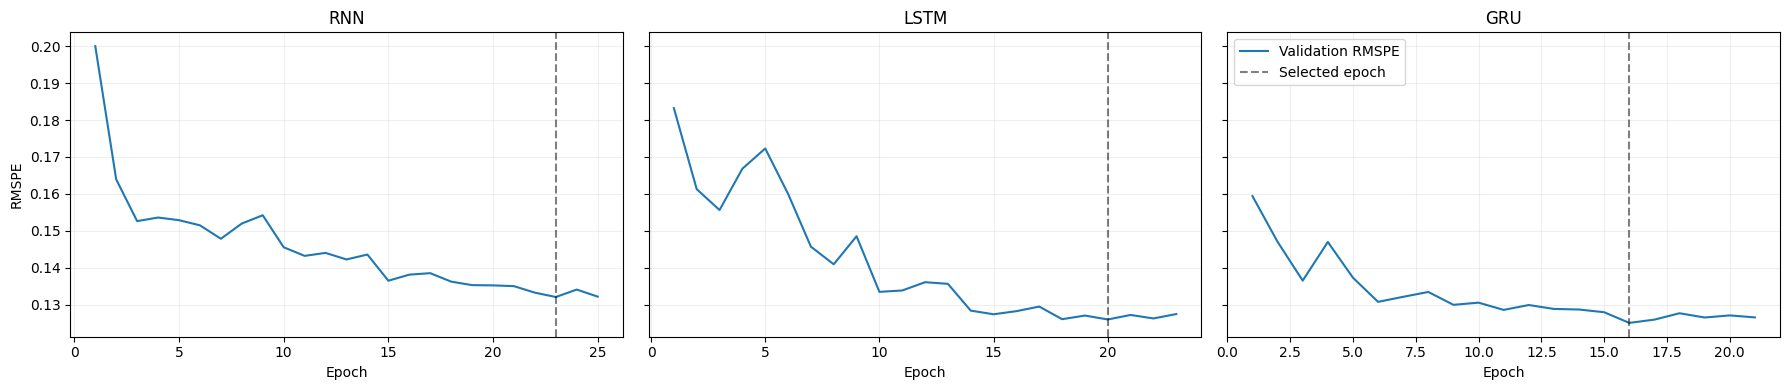

In [20]:
optimized_recurrent_models = {}
optimized_recurrent_histories = {}
optimized_validation_metrics = {}

for model_type in MODEL_TYPES:
    params = selected_recurrent_params[model_type]
    validation_max_epochs = max(
        int(BAYES_SEARCH["max_epochs"]),
        int(params["best_epoch"]) + int(BAYES_SEARCH["patience"]),
    )
    selected_model, selected_history, selected_epoch, selected_metrics = bo_fit_recurrent_candidate(
        params, train_dataset, val_inputs, val_rows, val_labels,
        random_state=BAYES_RANDOM_STATE,
        max_epochs=validation_max_epochs,
        patience=BAYES_SEARCH["patience"],
        min_delta=BAYES_MIN_DELTA,
        validation_batch_size=BAYES_VALIDATION_BATCH_SIZE,
    )
    optimized_recurrent_models[model_type] = selected_model
    optimized_recurrent_histories[model_type] = pd.DataFrame(selected_history)
    optimized_validation_metrics[model_type] = {"best_epoch": selected_epoch, **selected_metrics}

comparison_rows = []
baseline_lookup = globals().get("baseline_recurrent_metrics", {})
for model_type in MODEL_TYPES:
    baseline_rmspe = float(baseline_lookup.get(model_type, {}).get("rmspe", np.nan))
    optimized_rmspe = float(optimized_validation_metrics[model_type]["rmspe"])
    reduction = baseline_rmspe - optimized_rmspe if np.isfinite(baseline_rmspe) else np.nan
    comparison_rows.append({
        "model_type": model_type,
        "baseline_val_rmspe": baseline_rmspe,
        "optimized_val_rmspe": optimized_rmspe,
        "absolute_rmspe_reduction": reduction,
        "relative_improvement_pct": (100.0 * reduction / baseline_rmspe)
        if np.isfinite(baseline_rmspe) and baseline_rmspe > 0 else np.nan,
        "optimized_val_rmse": optimized_validation_metrics[model_type]["rmse"],
        "optimized_val_mae": optimized_validation_metrics[model_type]["mae"],
        "optimized_val_r2": optimized_validation_metrics[model_type]["r2"],
        "selected_epoch": optimized_validation_metrics[model_type]["best_epoch"],
    })

bayesian_validation_comparison = pd.DataFrame(comparison_rows).set_index("model_type")
display(bayesian_validation_comparison)

fig, axes = plt.subplots(1, len(MODEL_TYPES), figsize=(18, 4), sharey=True)
for axis, model_type in zip(axes, MODEL_TYPES):
    history_frame = optimized_recurrent_histories[model_type]
    axis.plot(history_frame["epoch"], history_frame["val_rmspe"], label="Validation RMSPE")
    axis.axvline(
        optimized_validation_metrics[model_type]["best_epoch"],
        color="black", linestyle="--", alpha=0.5, label="Selected epoch",
    )
    axis.set(title=model_type, xlabel="Epoch")
    axis.grid(alpha=0.2)
axes[0].set_ylabel("RMSPE")
axes[-1].legend()
fig.tight_layout()
plt.show()

## Final development-set training and test forecasts

After hyperparameter selection and validation reporting are complete, each architecture is trained on the combined training and validation history for its selected epoch count. Test forecast histories therefore include all observed Sales through the day before the test period. This step does not change the validation comparison above.

In [ ]:
development_df = (
    pd.concat([train_df, val_df], ignore_index=True)
    .sort_values(["Store", "Date"])
    .reset_index(drop=True)
)
development_recurrent_dataset = Training_options.SalesWindowDataset(
    development_df, lookBack, horizon, trainStride, store_to_index,
    numeric_features, numeric_means, category_levels, numeric_stds, sales_mean, sales_std,
)
final_test_inputs, final_test_rows = Training_options.make_forecast_inputs(
    development_df, test_df.drop(columns="Id"), horizon, lookBack, store_to_index,
    numeric_features, numeric_means, category_levels, numeric_stds, sales_mean, sales_std,
)

RUN_DIR.mkdir(parents=True, exist_ok=True)
bayesian_final_models = {}
bayesian_final_histories = {}
bayesian_test_predictions = {}
final_artifacts = []

for model_type in MODEL_TYPES:
    params = selected_recurrent_params[model_type]
    final_epochs = max(1, int(params["best_epoch"]))
    final_model, final_history = bo_train_recurrent_fixed_epochs(
        params, development_recurrent_dataset, final_epochs, BAYES_RANDOM_STATE
    )
    final_scaled = bo_predict_recurrent_scaled(
        final_model, final_test_inputs, horizon, BAYES_VALIDATION_BATCH_SIZE, device
    )
    final_sales = Training_options.decode_sales(
        final_scaled, final_test_rows["Open"].to_numpy(), sales_std, sales_mean
    )

    prediction_frame = final_test_rows[["Store", "Date"]].copy()
    if "Id" in test_df.columns:
        prediction_frame = prediction_frame.merge(
            test_df[["Store", "Date", "Id"]],
            on=["Store", "Date"], how="left", validate="one_to_one", sort=False,
        )
    prediction_frame["Sales"] = final_sales
    if "Id" in prediction_frame.columns:
        prediction_frame = prediction_frame.sort_values("Id").reset_index(drop=True)

    prediction_path = RUN_DIR / f"{model_type.lower()}_bayesian_test_predictions.csv"
    model_path = RUN_DIR / f"{model_type.lower()}_bayesian_state_dict.pt"
    prediction_frame.to_csv(prediction_path, index=False)
    torch.save(final_model.state_dict(), model_path)

    bayesian_final_models[model_type] = final_model
    bayesian_final_histories[model_type] = final_history
    bayesian_test_predictions[model_type] = prediction_frame
    final_artifacts.append({
        "model_type": model_type,
        "epochs": final_epochs,
        "prediction_rows": len(prediction_frame),
        "prediction_file": str(prediction_path),
        "model_file": str(model_path),
    })

display(pd.DataFrame(final_artifacts).set_index("model_type"))
display(bayesian_test_predictions["GRU"].head())